In [ ]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
fake = Faker()

In [ ]:
n = 100000

In [ ]:
data = []

In [ ]:
for i in range(n):

    age = random.randint(18, 70)

    gender = random.choice(['Male', 'Female'])

    tenure = random.randint(0, 10)

    balance = round(random.uniform(0, 200000), 2)

    credit_score = random.randint(300, 900)

    salary = round(random.uniform(10000, 150000), 2)

    products = random.randint(1, 4)

    active = random.choice([0, 1])

In [ ]:
churn = 1 if (balance < 50000 and active == 0 and credit_score < 500) else 0

In [ ]:
 data.append([
        fake.uuid4(), age, gender, tenure, balance,
        credit_score, salary, products, active, churn
    ])


In [ ]:
columns = [
    "Customer_ID",
    "Age",
    "Gender",
    "Tenure",
    "Balance",
    "CreditScore",
    "EstimatedSalary",
    "NumOfProducts",
    "IsActiveMember",
    "Churn"
]

In [ ]:

df = pd.DataFrame(data, columns=columns)


In [ ]:
df.to_csv("customer_churn_data.csv", index=False)

In [ ]:
print("Dataset Created Successfully!")


Dataset Created Successfully!


In [ ]:
print(df.head())


                            Customer_ID  Age Gender  Tenure   Balance  \
0  46b7fce8-9c3f-4456-96f4-d0bce0b2daef   32   Male       9  42264.53   

   CreditScore  EstimatedSalary  NumOfProducts  IsActiveMember  Churn  
0          324         47261.08              4               0      1  


In [ ]:
print("\nMissing Values:\n")
print(df.isnull().sum())



Missing Values:

Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64


In [ ]:
print("\nMean:\n")
print(df.mean(numeric_only=True))




Mean:

Age                   32.00
Tenure                 9.00
Balance            42264.53
CreditScore          324.00
EstimatedSalary    47261.08
NumOfProducts          4.00
IsActiveMember         0.00
Churn                  1.00
dtype: float64


In [ ]:
print("\nMedian:\n")
print(df.median(numeric_only=True))



Median:

Age                   32.00
Tenure                 9.00
Balance            42264.53
CreditScore          324.00
EstimatedSalary    47261.08
NumOfProducts          4.00
IsActiveMember         0.00
Churn                  1.00
dtype: float64


In [ ]:
print("\nStandard Deviation:\n")
print(df.std(numeric_only=True))



Standard Deviation:

Age               NaN
Tenure            NaN
Balance           NaN
CreditScore       NaN
EstimatedSalary   NaN
NumOfProducts     NaN
IsActiveMember    NaN
Churn             NaN
dtype: float64


In [ ]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100

In [ ]:

print("\nChurn Percentage:\n")
print(churn_rate)


Churn Percentage:

Churn
1    100.0
Name: proportion, dtype: float64


/tmp/ipykernel_3243/3699208150.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


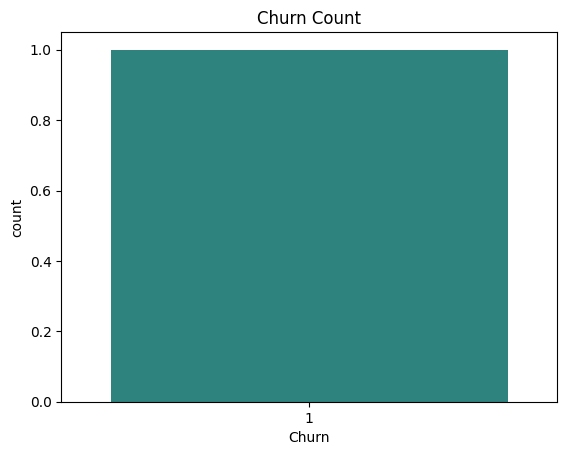

In [ ]:
sns.countplot(x='Churn', data=df, palette='viridis')

plt.title("Churn Count")

plt.show()

<Axes: xlabel='Gender', ylabel='count'>

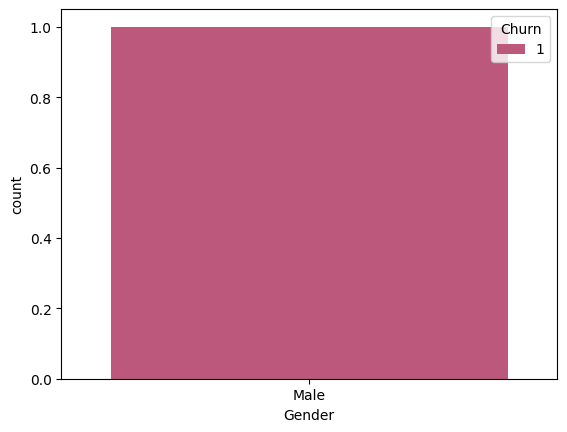

In [ ]:
sns.countplot(
    x='Gender',
    hue='Churn',
    data=df,
    palette='plasma'
)

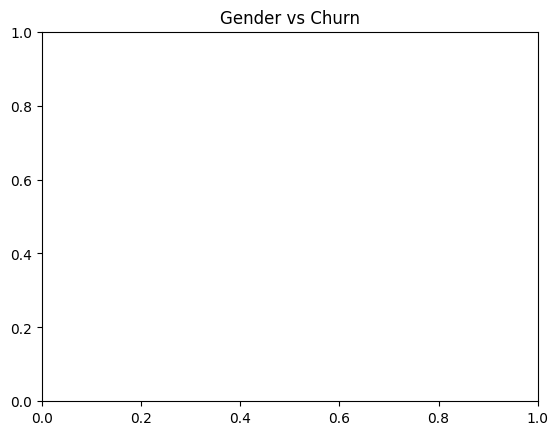

In [ ]:
plt.title("Gender vs Churn")

plt.show()

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([31.5       , 31.53333333, 31.56666667, 31.6       , 31.63333333,
        31.66666667, 31.7       , 31.73333333, 31.76666667, 31.8       ,
        31.83333333, 31.86666667, 31.9       , 31.93333333, 31.96666667,
        32.        , 32.03333333, 32.06666667, 32.1       , 32.13333333,
        32.16666667, 32.2       , 32.23333333, 32.26666667, 32.3       ,
        32.33333333, 32.36666667, 32.4       , 32.43333333, 32.46666667,
        32.5       ]),
 <BarContainer object of 30 artists>)

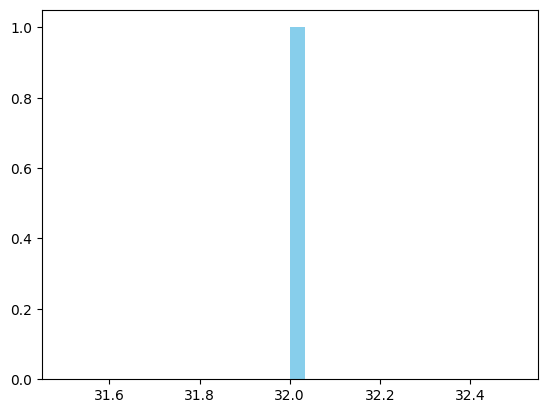

In [ ]:
plt.hist(
    df['Age'],
    bins=30,
    color='skyblue'
)


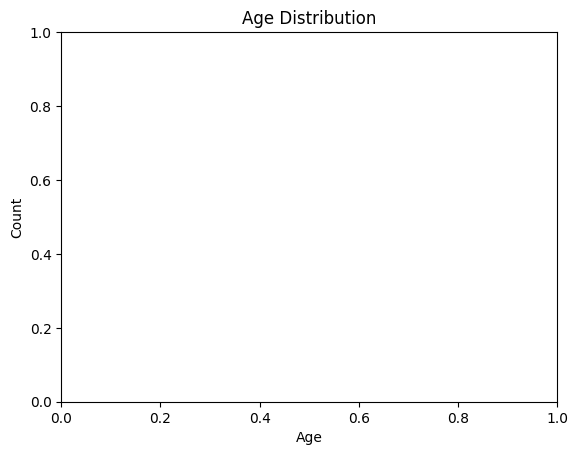

In [ ]:
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


/tmp/ipykernel_3243/1462702491.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


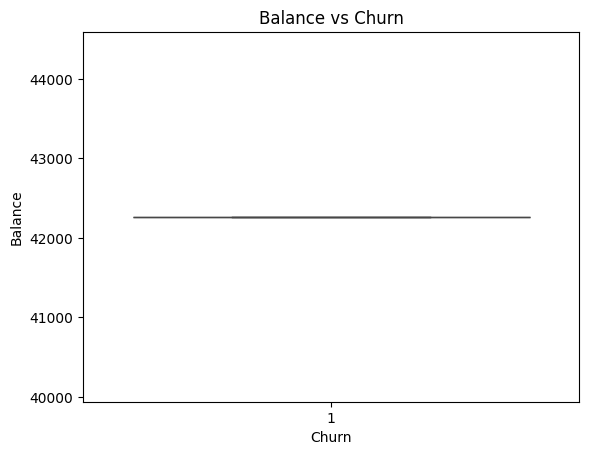

In [ ]:
sns.boxplot(
    x='Churn',
    y='Balance',
    data=df,
    palette='magma'
)

plt.title("Balance vs Churn")

plt.show()

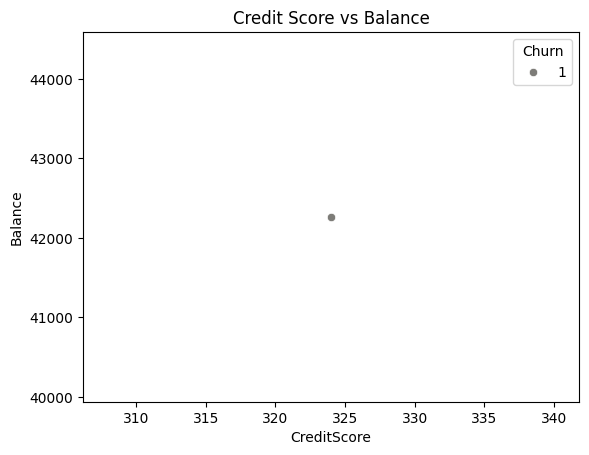

In [ ]:
sns.scatterplot(
    x='CreditScore',
    y='Balance',
    hue='Churn',
    data=df,
    palette='cividis'
)

plt.title("Credit Score vs Balance")

plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


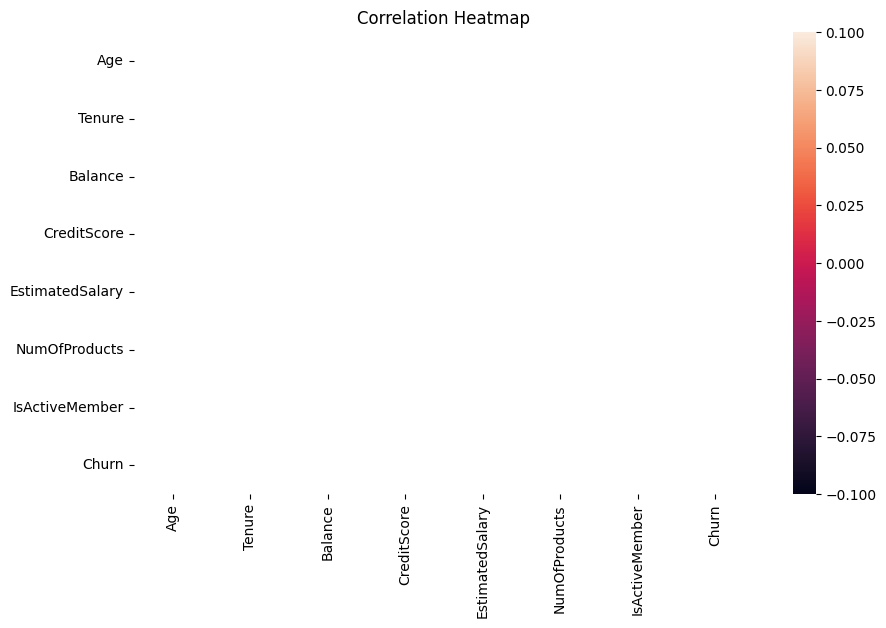

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='rocket'
)

plt.title("Correlation Heatmap")

plt.show()


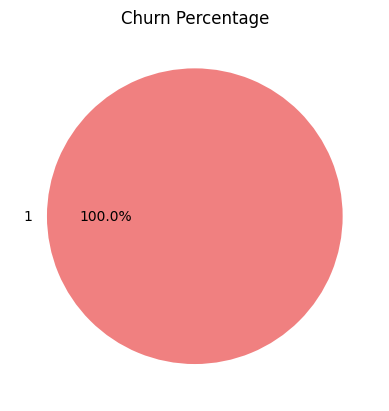

In [ ]:
df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['lightcoral', 'lightskyblue']
)

plt.title("Churn Percentage")

plt.ylabel("")

plt.show()


In [ ]:
print("\nDataset Shape:", df.shape)

print("\nDataset Information:\n")

print(df.info())


Dataset Shape: (1, 10)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1 non-null      object 
 1   Age              1 non-null      int64  
 2   Gender           1 non-null      object 
 3   Tenure           1 non-null      int64  
 4   Balance          1 non-null      float64
 5   CreditScore      1 non-null      int64  
 6   EstimatedSalary  1 non-null      float64
 7   NumOfProducts    1 non-null      int64  
 8   IsActiveMember   1 non-null      int64  
 9   Churn            1 non-null      int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 212.0+ bytes
None
